In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
# df2["Peritonitis"].value_counts()

In [54]:
# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)

In [55]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [56]:
# df2["Diagnosis"].corr(df2["Peritonitis"])

In [57]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

In [58]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)
df2["Peritonitis"].value_counts()

0    189
1     49
Name: Peritonitis, dtype: int64

In [59]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.19028246913072036

In [60]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [61]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [62]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [63]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [64]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [65]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

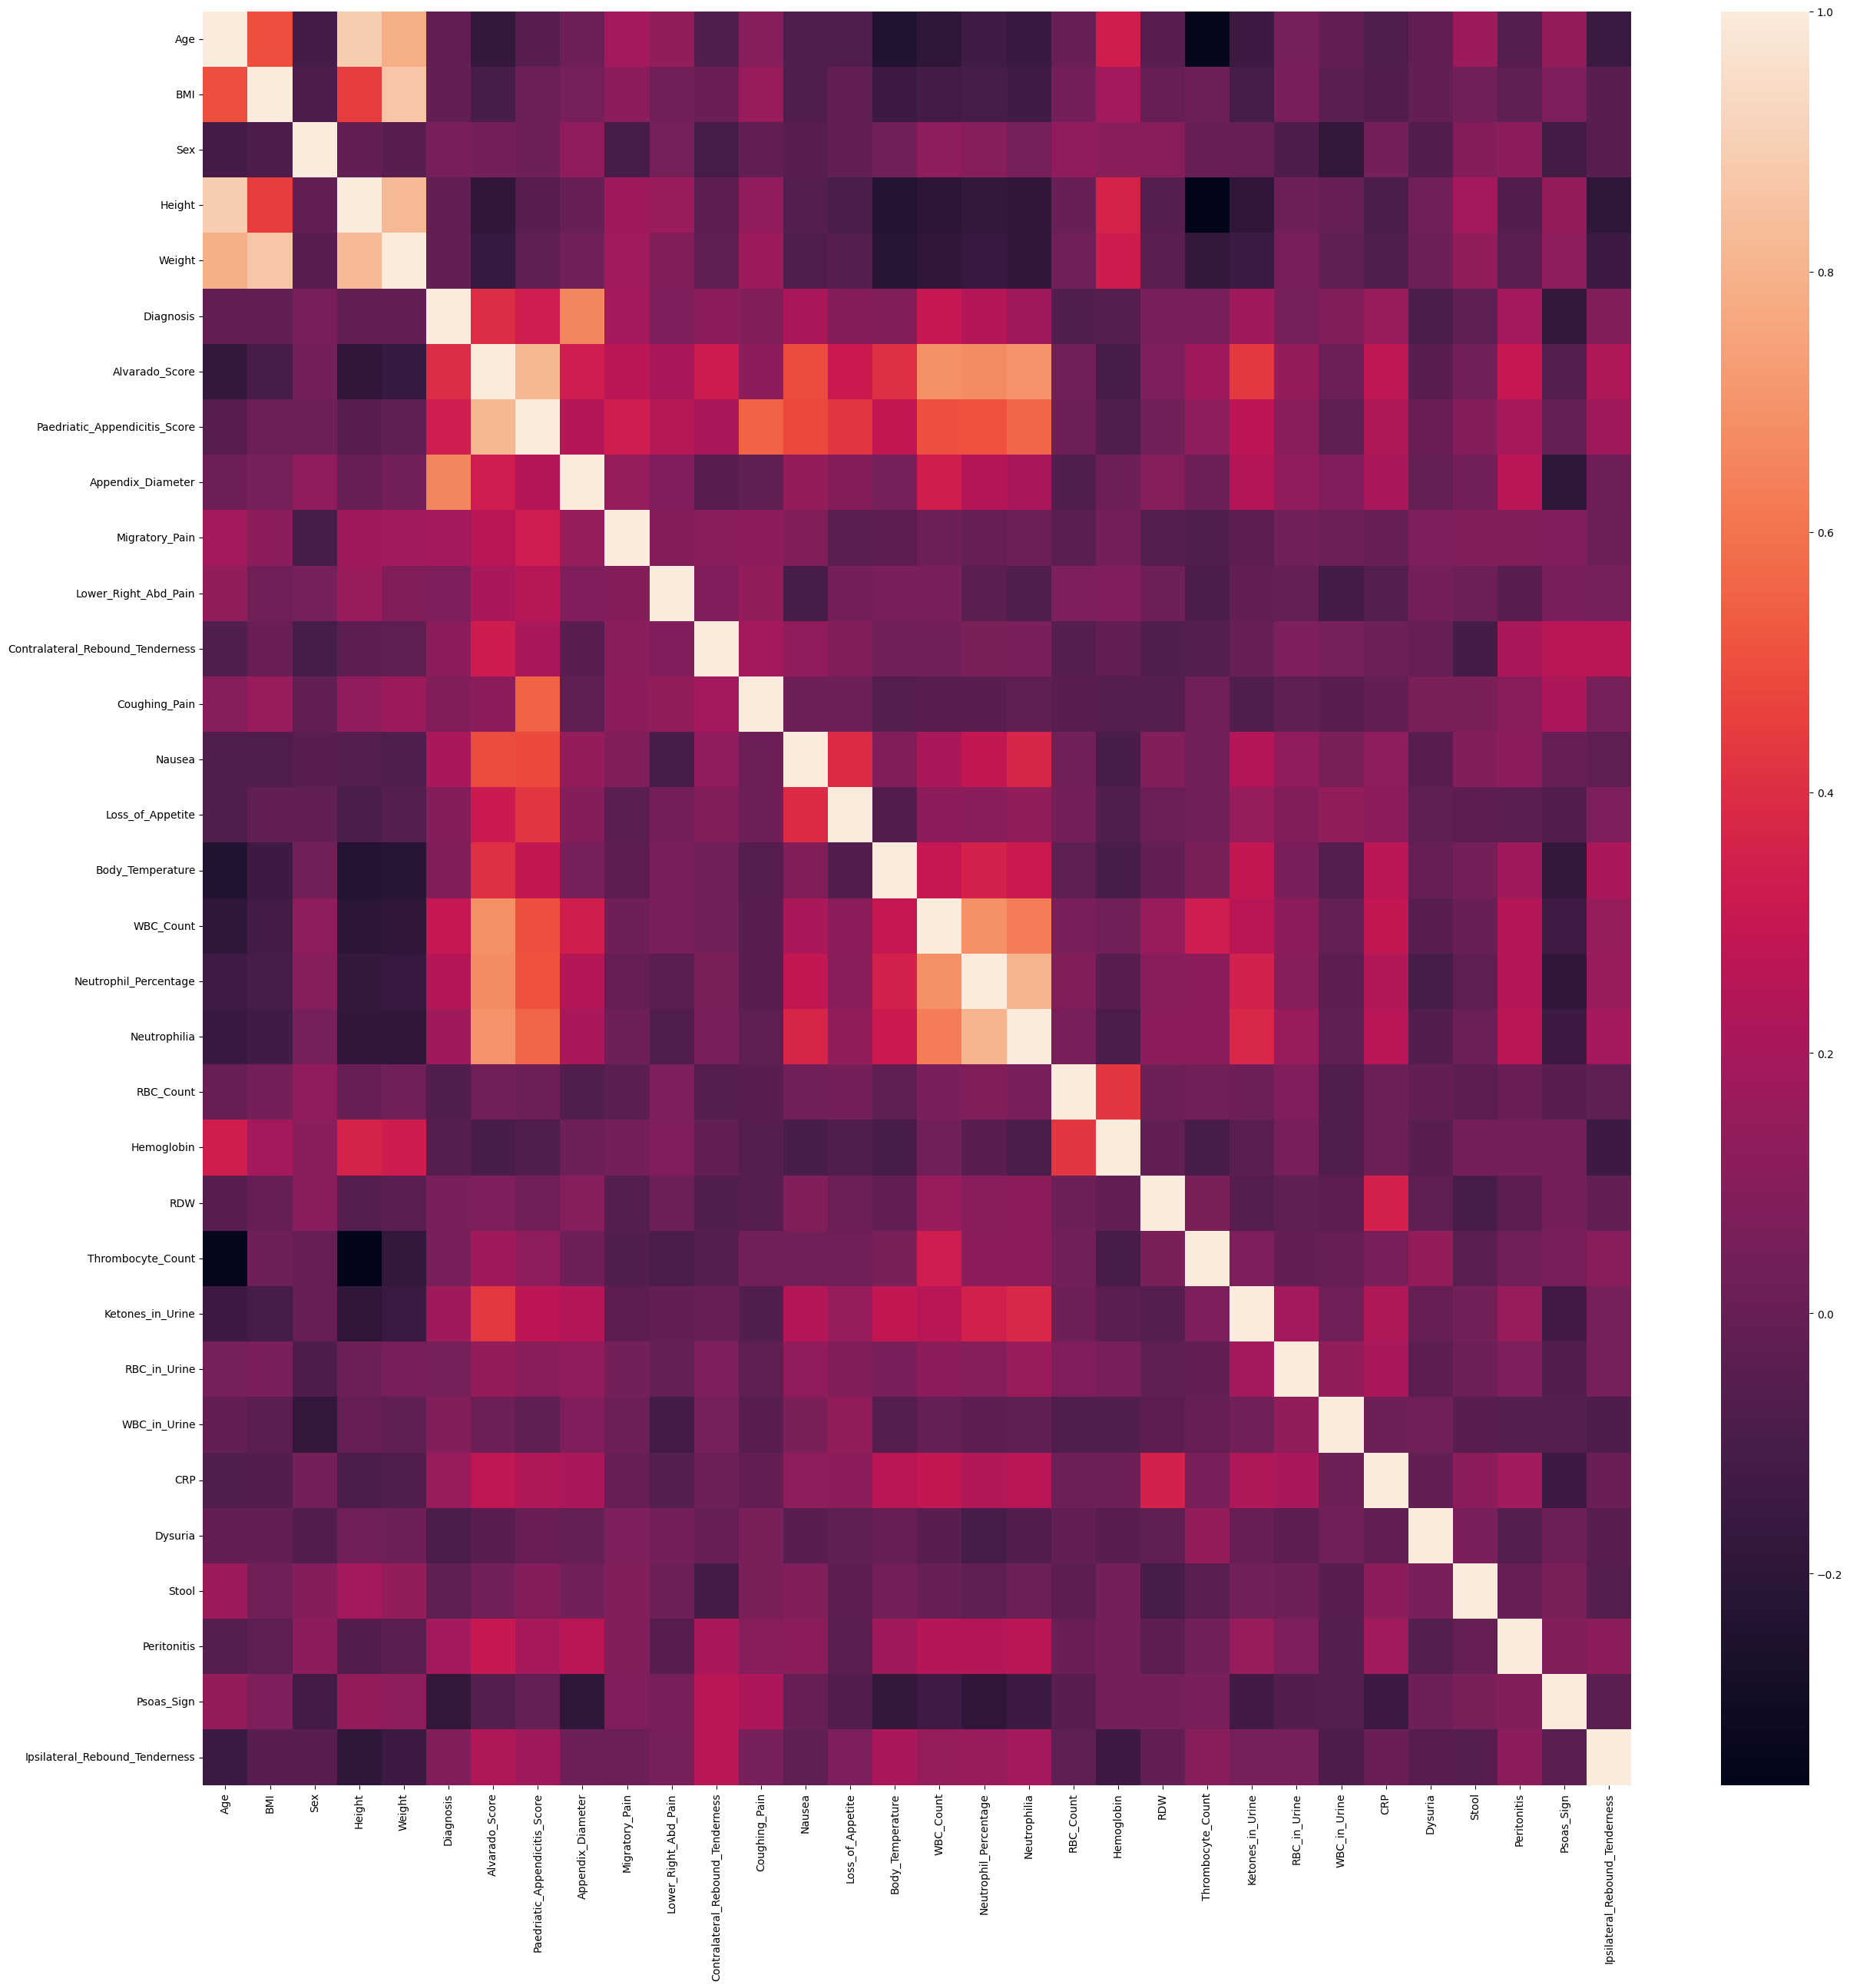

In [66]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [67]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [68]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [69]:
# dsafsf

In [70]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING INFORMATION GAIN FOR FEATURE SELECTION

Index(['BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Nausea', 'Loss_of_Appetite',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage',
       'Neutrophilia', 'RBC_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

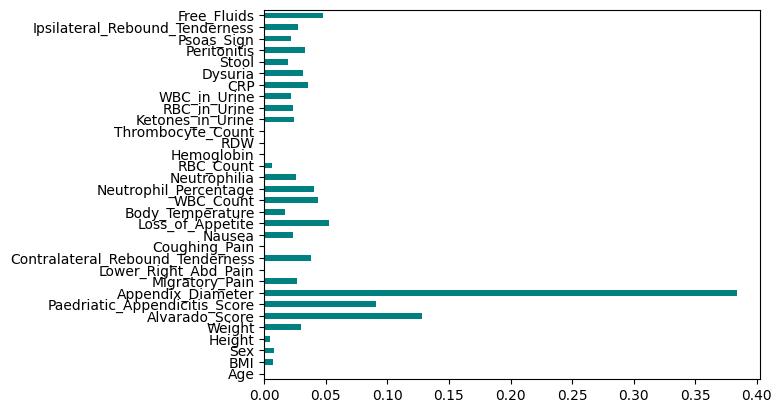

In [71]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)


cols = mutual_info[mutual_info>0].index
cols

In [72]:
df["Peritonitis"].value_counts()

no             540
local          192
generalized     41
Name: Peritonitis, dtype: int64

In [73]:
col =list(cols)
col.append("Diagnosis")
df = df.loc[:,col]

In [74]:
col

['BMI',
 'Sex',
 'Height',
 'Weight',
 'Alvarado_Score',
 'Paedriatic_Appendicitis_Score',
 'Appendix_Diameter',
 'Migratory_Pain',
 'Contralateral_Rebound_Tenderness',
 'Nausea',
 'Loss_of_Appetite',
 'Body_Temperature',
 'WBC_Count',
 'Neutrophil_Percentage',
 'Neutrophilia',
 'RBC_Count',
 'Ketones_in_Urine',
 'RBC_in_Urine',
 'WBC_in_Urine',
 'CRP',
 'Dysuria',
 'Stool',
 'Peritonitis',
 'Psoas_Sign',
 'Ipsilateral_Rebound_Tenderness',
 'Free_Fluids',
 'Diagnosis']

In [75]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [76]:
# df4 = df.dropna()
# aaaaaaaaaa

In [77]:
# df4.shape
df2["Free_Fluids"].value_counts()

0    142
1     96
Name: Free_Fluids, dtype: int64

C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\4212803033.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()
C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\4212803033.py:333: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]
C:\Users\shadj\AppData\Local\Temp\ipykernel_35072\4212803033.py:340: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 241 entries, 0 to 780
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BMI                               241 non-null    float64
 1   Sex                               241 non-null    int32  
 2   Height                            241 non-null    float64
 3   Weight                            241 non-null    float64
 4   Alvarado_Score                    241 non-null    float64
 5   Paedriatic_Appendicitis_Score     241 non-null    float64
 6   Appendix_Diameter                 241 non-null    float64
 7   Migratory_Pain                    241 non-null    int32  
 8   Contralateral_Rebound_Tenderness  241 non-null    int32  
 9   Nausea                            241 non-null    int32  
 10  Loss_of_Appetite                  241 non-null    int32  
 11  Body_Temperature                  241 non-null    float64
 12  WBC_Coun

1    160
0     81
Name: Diagnosis, dtype: int64

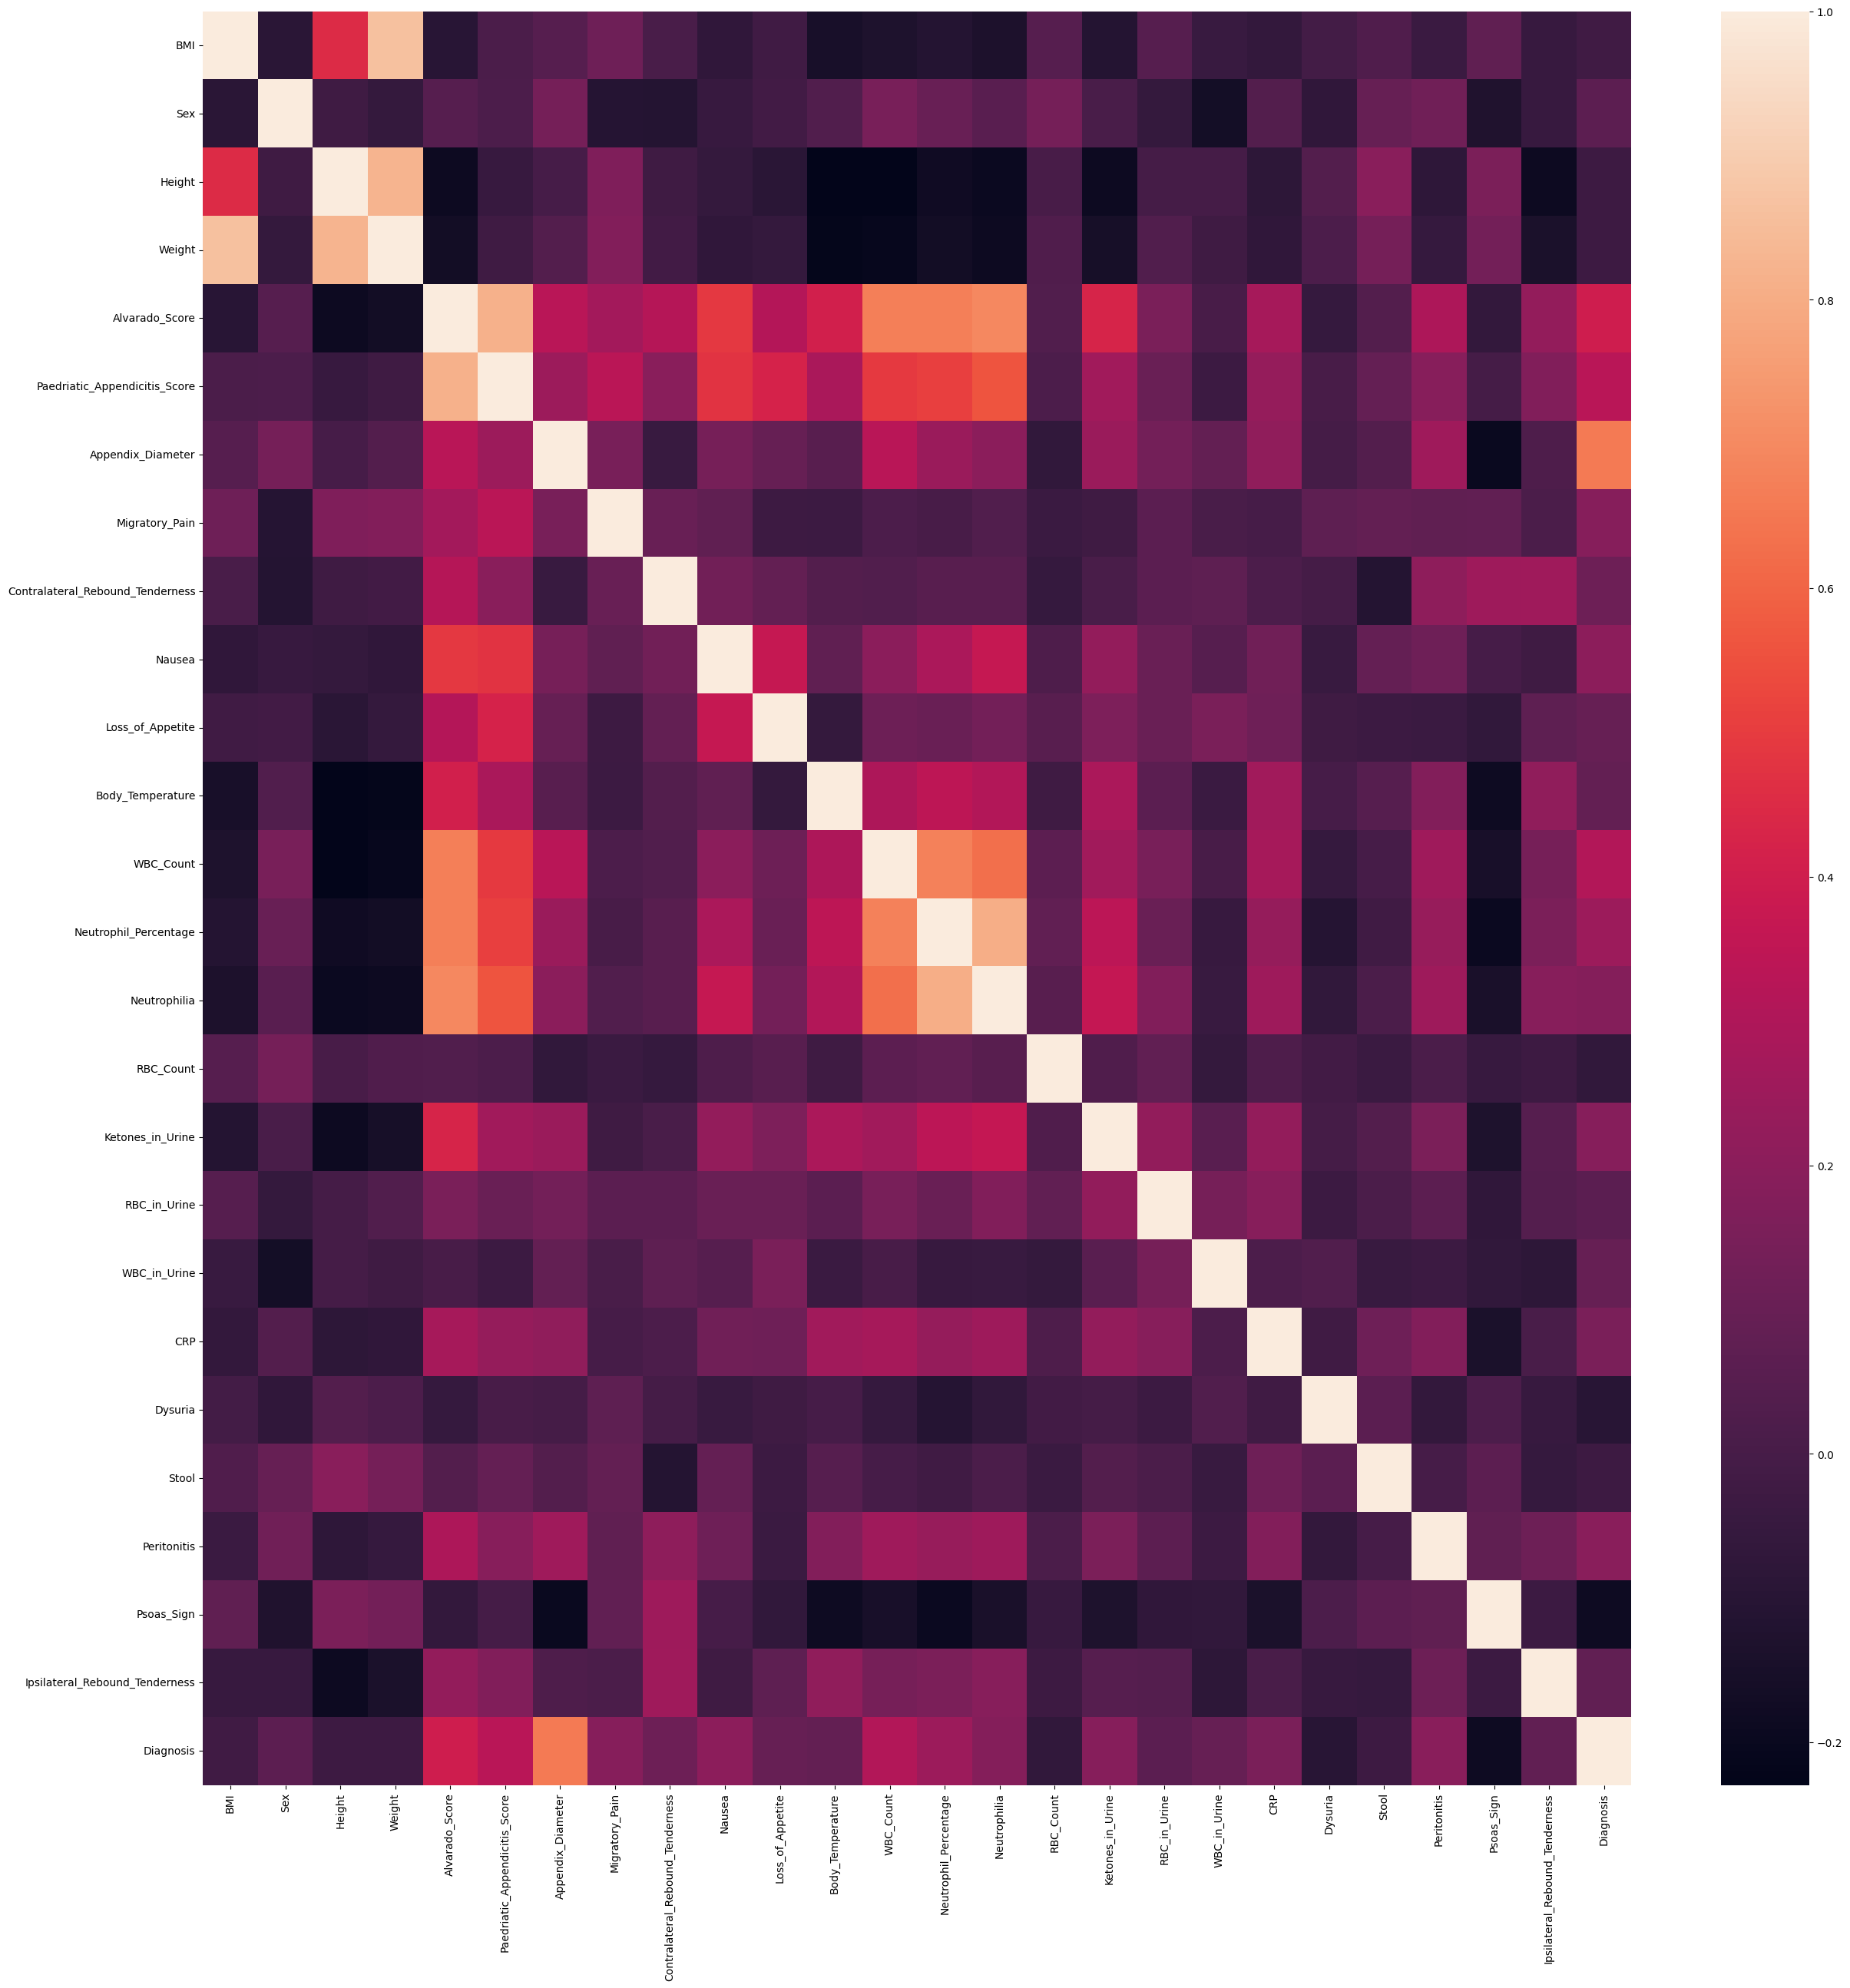

In [78]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


# df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


# df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


# df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


# df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
# df2["Coughing_Pain"].value_counts()


# In[36]:


# df2["Nausea"].value_counts(dropna = False)


# In[37]:


df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()


# In[38]:


# df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()


# In[40]:


# df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()


# In[42]:


# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


# df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)


# In[53]:


df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [79]:
# x.info()

In [80]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(241, 26)

In [81]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 241 entries, 0 to 780
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BMI                               241 non-null    float64
 1   Sex                               241 non-null    int32  
 2   Height                            241 non-null    float64
 3   Weight                            241 non-null    float64
 4   Alvarado_Score                    241 non-null    float64
 5   Paedriatic_Appendicitis_Score     241 non-null    float64
 6   Appendix_Diameter                 241 non-null    float64
 7   Migratory_Pain                    241 non-null    int32  
 8   Contralateral_Rebound_Tenderness  241 non-null    int32  
 9   Nausea                            241 non-null    int32  
 10  Loss_of_Appetite                  241 non-null    int32  
 11  Body_Temperature                  241 non-null    float64
 12  WBC_Coun

In [82]:
y.value_counts()

1    160
0     81
Name: Diagnosis, dtype: int64

In [83]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 241 entries, 0 to 780
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BMI                               241 non-null    float64
 1   Sex                               241 non-null    int32  
 2   Height                            241 non-null    float64
 3   Weight                            241 non-null    float64
 4   Alvarado_Score                    241 non-null    float64
 5   Paedriatic_Appendicitis_Score     241 non-null    float64
 6   Appendix_Diameter                 241 non-null    float64
 7   Migratory_Pain                    241 non-null    int32  
 8   Contralateral_Rebound_Tenderness  241 non-null    int32  
 9   Nausea                            241 non-null    int32  
 10  Loss_of_Appetite                  241 non-null    int32  
 11  Body_Temperature                  241 non-null    float64
 12  WBC_Coun

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [86]:
x_train.shape

(192, 26)

In [87]:
# y_train.value_counts()

In [88]:
# col
x_train.columns

Index(['BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Nausea', 'Loss_of_Appetite',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage',
       'Neutrophilia', 'RBC_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

In [89]:
y_test.value_counts()
y_train.value_counts()

1    123
0     69
Name: Diagnosis, dtype: int64

In [90]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.84      0.73      0.78        37

    accuracy                           0.69        49
   macro avg       0.63      0.66      0.63        49
weighted avg       0.74      0.69      0.71        49



In [91]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.64 ± 0.05
TEST_F1 - Mean: 0.74 ± 0.04
TEST_ROC_AUC - Mean: 0.66 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.77 ± 0.07
TEST_PRECISION - Mean: 0.71 ± 0.09
TEST_RECALL - Mean: 0.78 ± 0.04


In [92]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9051
Fold 2: AUPR = 0.7548
Fold 3: AUPR = 0.7663
Fold 4: AUPR = 0.8599
Fold 5: AUPR = 0.7645

Average AUPR: 0.81 +- 0.06


In [93]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.45      0.75      0.56        12
           1       0.90      0.70      0.79        37

    accuracy                           0.71        49
   macro avg       0.67      0.73      0.68        49
weighted avg       0.79      0.71      0.73        49



In [94]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.77 ± 0.04
TEST_F1 - Mean: 0.81 ± 0.04
TEST_ROC_AUC - Mean: 0.84 ± 0.06
TEST_AVERAGE_PRECISION - Mean: 0.89 ± 0.06
TEST_PRECISION - Mean: 0.87 ± 0.07
TEST_RECALL - Mean: 0.77 ± 0.04


In [95]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9013
Fold 2: AUPR = 0.8927
Fold 3: AUPR = 0.7713
Fold 4: AUPR = 0.9007
Fold 5: AUPR = 0.9537

Average AUPR: 0.88 +- 0.06


In [96]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.76      1.00      0.86        37

    accuracy                           0.76        49
   macro avg       0.38      0.50      0.43        49
weighted avg       0.57      0.76      0.65        49



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [97]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.66 ± 0.07
TEST_F1 - Mean: 0.80 ± 0.05
TEST_ROC_AUC - Mean: 0.84 ± 0.09
TEST_AVERAGE_PRECISION - Mean: 0.93 ± 0.03
TEST_PRECISION - Mean: 0.66 ± 0.07
TEST_RECALL - Mean: 1.00 ± 0.00


In [98]:
# This will not work here

# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [99]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.97      0.95      0.96        37

    accuracy                           0.94        49
   macro avg       0.91      0.93      0.92        49
weighted avg       0.94      0.94      0.94        49



In [100]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.01
TEST_ACCURACY - Mean: 0.98 ± 0.03
TEST_F1 - Mean: 0.98 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.02
TEST_PRECISION - Mean: 0.99 ± 0.01
TEST_RECALL - Mean: 0.97 ± 0.03


In [101]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9795
Fold 2: AUPR = 1.0000
Fold 3: AUPR = 0.9851
Fold 4: AUPR = 1.0000
Fold 5: AUPR = 1.0000

Average AUPR: 0.9929 +- 0.01


In [102]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.92      0.97      0.94        35

    accuracy                           0.92        49
   macro avg       0.92      0.88      0.90        49
weighted avg       0.92      0.92      0.92        49



In [104]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.15 ± 0.02
SCORE_TIME - Mean: 0.02 ± 0.01
TEST_ACCURACY - Mean: 0.96 ± 0.03
TEST_F1 - Mean: 0.97 ± 0.03
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.98 ± 0.03
TEST_RECALL - Mean: 0.96 ± 0.04


In [105]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9931
Fold 2: AUPR = 0.9950
Fold 3: AUPR = 0.9852
Fold 4: AUPR = 1.0000
Fold 5: AUPR = 1.0000

Average AUPR: 0.9947 +- 0.01


In [106]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.95      0.97        37

    accuracy                           0.96        49
   macro avg       0.93      0.97      0.95        49
weighted avg       0.97      0.96      0.96        49



In [107]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.03 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.00
TEST_ACCURACY - Mean: 0.98 ± 0.02
TEST_F1 - Mean: 0.99 ± 0.02
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.01
TEST_PRECISION - Mean: 1.00 ± 0.00
TEST_RECALL - Mean: 0.97 ± 0.03


In [108]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9954
Fold 2: AUPR = 1.0000
Fold 3: AUPR = 0.9809
Fold 4: AUPR = 1.0000
Fold 5: AUPR = 1.0000

Average AUPR: 1.00 +- 0.01


In [109]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.95      0.97        37

    accuracy                           0.96        49
   macro avg       0.93      0.97      0.95        49
weighted avg       0.97      0.96      0.96        49



In [110]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.02 ± 0.01
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.97 ± 0.01
TEST_F1 - Mean: 0.97 ± 0.01
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [111]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9941
Fold 2: AUPR = 0.9818
Fold 3: AUPR = 0.9794
Fold 4: AUPR = 0.9990
Fold 5: AUPR = 0.9984

Average AUPR: 0.9905 +- 0.01


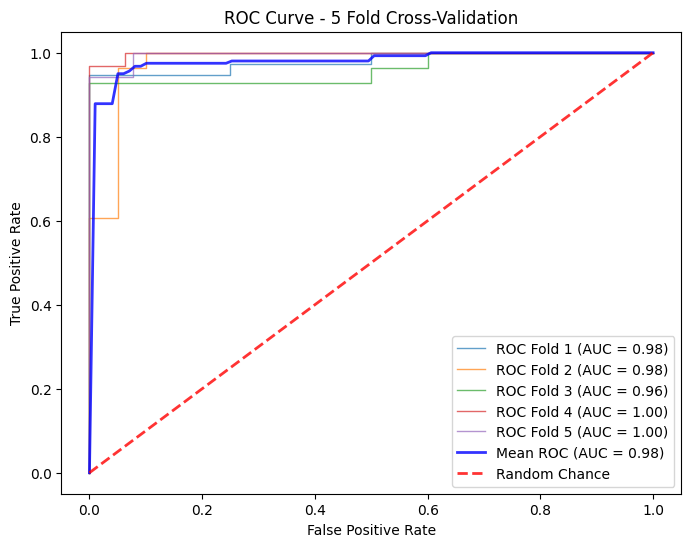

In [112]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= x
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()

In [113]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.89      0.92      0.91        37

    accuracy                           0.86        49
   macro avg       0.81      0.79      0.80        49
weighted avg       0.85      0.86      0.85        49



In [114]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.12 ± 0.01
SCORE_TIME - Mean: 0.02 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.05
TEST_F1 - Mean: 0.96 ± 0.03
TEST_ROC_AUC - Mean: 0.98 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [115]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9903
Fold 2: AUPR = 0.9936
Fold 3: AUPR = 0.9929
Fold 4: AUPR = 1.0000
Fold 5: AUPR = 0.9750

Average AUPR: 0.9903 +- 0.01


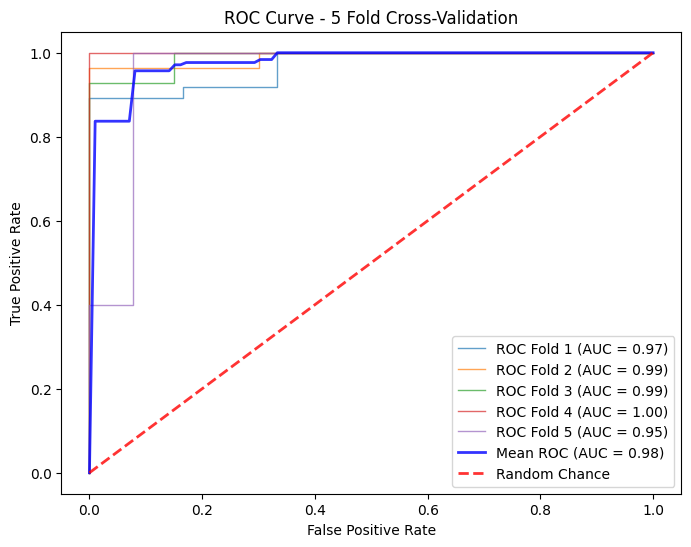

In [116]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= x
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

In [ ]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = X.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# from sklearn.model_selection import KFold, cross_val_score,cross_validate

# # X= pd.concat([x_train,x_test])
# # y= pd.concat([y_train,y_test])
# X = x
# scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# # Define the number of folds (k)
# k = 5
# kf = KFold(n_splits=k, shuffle=True, random_state=42)

# result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

In [ ]:
# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [ ]:
# # Working code for plotting ROC Curve

# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc
# from sklearn.model_selection import KFold
# import numpy as np

# # Assuming you have your data and model ready
# # X = x
# X= x
# # y = your_labels  # Target variable

# # Initialize KFold with 5 folds
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# plt.figure(figsize=(8, 6))

# # Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
# mean_tpr = 0.0
# mean_fpr = np.linspace(0, 1, 100)
# all_tpr = []

# for i, (train_index, test_index) in enumerate(kf.split(X)):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

#     # Fit your model
#     model.fit(X_train, Y_train)

#     # Predict probabilities for positive class
#     y_pred_proba = model.predict_proba(X_test)[:, 1]

#     # Compute ROC curve and area under the curve
#     fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
#     roc_auc = auc(fpr, tpr)

#     # Plot ROC curve for this fold
#     plt.plot(fpr, tpr, lw=1, alpha=0.7,
#              label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

#     # Interpolate tpr at mean_fpr
#     mean_tpr += np.interp(mean_fpr, fpr, tpr)
#     mean_tpr[0] = 0.0

# # Calculate mean of tprs and auc across all folds
# mean_tpr /= kf.get_n_splits(X)
# mean_auc = auc(mean_fpr, mean_tpr)

# # Plot mean ROC curve
# plt.plot(mean_fpr, mean_tpr, color='b',
#          label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# # Plot the random chance line
# plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
#          label='Random Chance', alpha=.8)

# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve - 5 Fold Cross-Validation')
# plt.legend(loc='lower right')
# plt.show()


In [ ]:
y.value_counts()

C:\Users\shadj\Python\Python310\lib\site-packages\numpy\core\_methods.py:164: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asanyarray(a)


ValueError: operands could not be broadcast together with shapes (62,) (32,) 

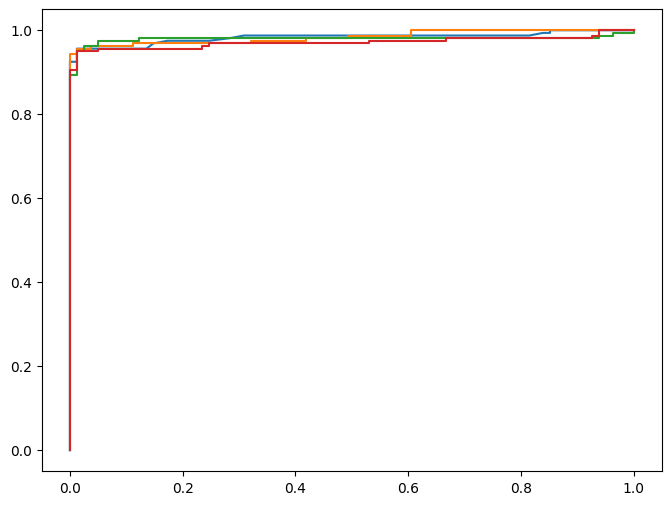

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Generate sample data
# X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X,y = x,y
# Initialize classifiers
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = XGBClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)

classifiers = {'Random Forest': rf_clf, 'XGBoost': xgb_clf, 'LGBoost': lgb_clf, 'Adaboost': ada_clf}

# Plot AUROC curve
plt.figure(figsize=(8, 6))

for name, clf in classifiers.items():
    y_scores = cross_val_predict(clf, X, y, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([roc_curve(y, cross_val_predict(clf, X, y, cv=5, method='predict_proba')[:, 1])[1] for clf in classifiers.values()], axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, label=f'Mean ROC (AUC = {mean_auc:.2f})', linestyle='--', color='black')

plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\shadj\Python\Python310\lib\site-packages\numpy\core\_methods.py:164: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asanyarray(a)


ValueError: operands could not be broadcast together with shapes (62,) (32,) 

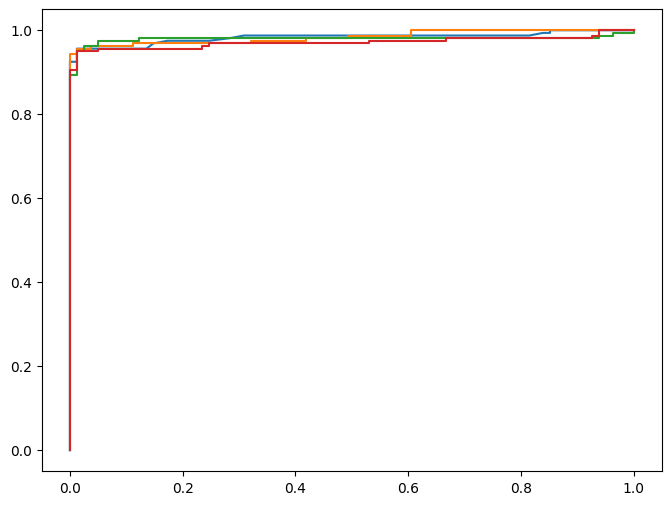

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Generate sample data
# X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X,y = x,y

# Initialize classifiers
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = XGBClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)

classifiers = {'Random Forest': rf_clf, 'XGBoost': xgb_clf, 'LGBoost': lgb_clf, 'Adaboost': ada_clf}

# Plot AUROC curve
plt.figure(figsize=(8, 6))

for name, clf in classifiers.items():
    y_scores = cross_val_predict(clf, X, y, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([roc_curve(y, cross_val_predict(clf, X, y, cv=5, method='predict_proba')[:, 1])[1] for clf in classifiers.values()], axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, label=f'Mean ROC (AUC = {mean_auc:.2f})', linestyle='--', color='black')

plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(0, 1.1, step=0.1))
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.show()


In [ ]:
Thoda rest karlijiye warn rest in peace ho jayegene

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))